# Groundwater Quality Data Standardization for ML

## Section 1: Imports & Load Dataset

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# For reference scaling (optional)
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Define file paths
INPUT_PATH = Path('../data/cleaned/groundwater_data_cleaned_final.csv')
OUTPUT_DIR = Path('../data/processed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)  # Create directory if it doesn't exist

# Load the dataset
print(f"Loading dataset from: {INPUT_PATH}")
try:
    df = pd.read_csv(INPUT_PATH)
    print(f"Successfully loaded dataset with shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: File not found at {INPUT_PATH}")
    # Create empty dataframe to allow notebook to continue
    df = pd.DataFrame()

# Display basic info
print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nFirst 3 records:")
display(df.head(3))

Loading dataset from: ..\data\cleaned\groundwater_data_cleaned_final.csv
Successfully loaded dataset with shape: (16079, 31)

DATASET OVERVIEW
Rows: 16,079
Columns: 31

First 3 records:


,S. No.,State,District,Location,Longitude,Latitude,Year,pH,EC_uScm,CO3_mgL,...,Fe_ppm,As_ppb,U_ppb,coordinate_flag,NO3_extreme_flag,district_raw,location_raw,district_clean,location_id,record_id
0,12001.0,Punjab,Mansa,Joga,75.4229,3.1611,2023.0,8.26,1880.0,0.0,...,0.63,0.89,16.77,INVALID,NaN,Mansa,Joga,mansa,3.1611_75.4229,0
1,11542.0,Punjab,Bathinda,Mehma Bhagwana,74.8162,3.2862,2023.0,8.14,2081.0,0.0,...,0.07,5.80,62.90,INVALID,NaN,Bathinda,Mehma Bhagwana,bathinda,3.2862_74.8162,1
2,12020.0,Punjab,Mansa,Kalho,75.2708,3.0292,2023.0,7.20,2333.0,0.0,...,0.25,3.52,25.57,INVALID,NaN,Mansa,Kalho,mansa,3.0292_75.2708,2


In [3]:
# Define required columns for verification
required_columns = [
    'pH', 'EC_uScm', 'HCO3_mgL', 'Cl_mgL', 'F_mgL',
    'SO4', 'NO3', 'Total_Hardness_mgL', 'Ca_mgL', 'Mg_mgL',
    'Na_mgL', 'K_mgL', 'coordinate_flag', 'Latitude', 'Longitude',
    'State', 'District'
]

# Check for required columns
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"Warning: Missing required columns: {missing_columns}")
else:
    print("All required columns are present in the dataset.")
    
# Check data types for key columns
print("\nData types for key columns:")
key_cols_info = df[['pH', 'EC_uScm', 'NO3', 'F_mgL', 'coordinate_flag']].dtypes
print(key_cols_info.to_string())

All required columns are present in the dataset.

Data types for key columns:
pH                 float64
EC_uScm            float64
NO3                float64
F_mgL              float64
coordinate_flag     object


# Section 2: Unit Standardization

### Total Dissolved Solids (TDS) Derivation
Total Dissolved Solids (TDS) is a critical water quality parameter representing the total concentration of dissolved substances in water. While direct TDS measurement is ideal, it can be reliably estimated from Electrical Conductivity (EC) using an empirical conversion factor.

**Conversion Rationale:**
- EC measures water's ability to conduct electricity, which correlates with ion concentration
- The factor 0.67 (mg/L per µS/cm) is widely accepted in hydrogeological literature
- This conversion provides a reasonable estimate of TDS for most natural waters
- Derived TDS enables comparison with drinking water standards (BIS: 500-2000 mg/L)

**Limitations:**
- Conversion assumes consistent ionic composition
- May overestimate TDS for waters with high organic content
- Factor may vary slightly based on water chemistry

Deriving Total Dissolved Solids (TDS) from Electrical Conductivity...

TDS Derivation Statistics:
• Records with valid EC values: 14,563 (90.6%)
• Records without EC (TDS set to NaN): 1,516

DERIVED TDS SUMMARY STATISTICS


,Value
Statistic,
count,14563.000000
mean,872.396451
std,1217.854528
min,8.040000
5%,131.990000
25%,366.490000
50%,588.260000
75%,951.400000
95%,2495.549000



------------------------------------------------------------
COMPARISON WITH BIS DRINKING WATER STANDARDS
------------------------------------------------------------
BIS Acceptable Limit: 500 mg/L
BIS Permissible Limit: 2000 mg/L

Exceedance Statistics:
• Samples exceeding acceptable limit: 8,634 (59.3%)
• Samples exceeding permissible limit: 1,085 (7.5%)


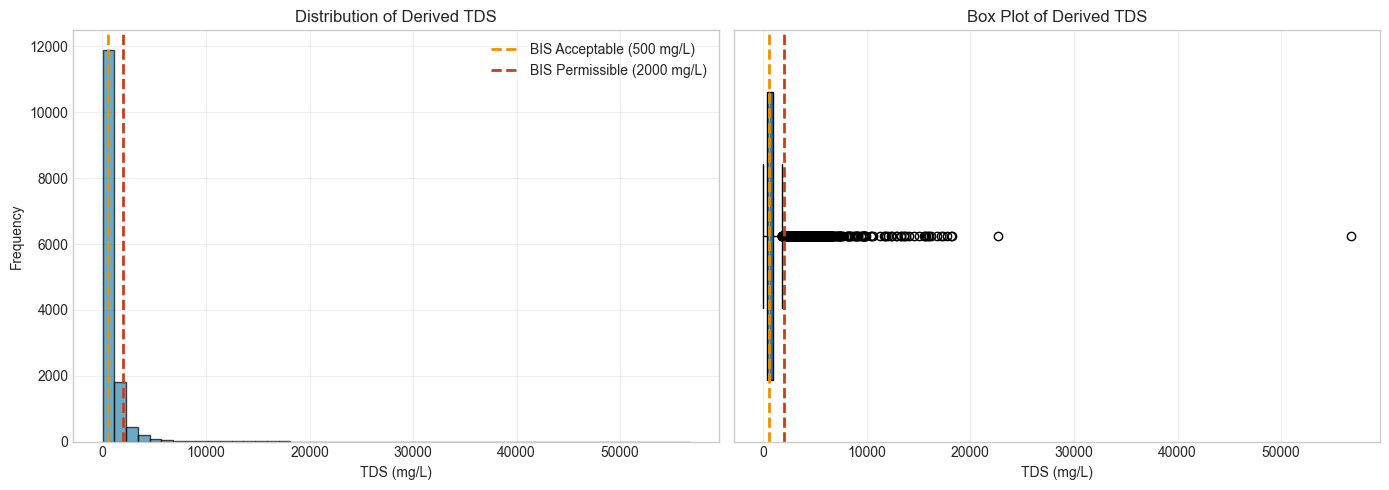

In [4]:
# Create TDS column using standard conversion factor
print("Deriving Total Dissolved Solids (TDS) from Electrical Conductivity...")

# Define conversion factor (standard hydrogeological conversion)
TDS_CONVERSION_FACTOR = 0.67  # mg/L per µS/cm

# Calculate TDS only for rows with valid EC values
valid_ec_mask = df['EC_uScm'].notna()
df['TDS_mgL'] = np.nan
df.loc[valid_ec_mask, 'TDS_mgL'] = df.loc[valid_ec_mask, 'EC_uScm'] * TDS_CONVERSION_FACTOR

# Calculate conversion statistics
converted_count = valid_ec_mask.sum()
total_count = len(df)
conversion_percentage = (converted_count / total_count) * 100

print(f"\nTDS Derivation Statistics:")
print(f"• Records with valid EC values: {converted_count:,} ({conversion_percentage:.1f}%)")
print(f"• Records without EC (TDS set to NaN): {total_count - converted_count:,}")

# Summary statistics for derived TDS
print("\n" + "="*60)
print("DERIVED TDS SUMMARY STATISTICS")
print("="*60)

tds_stats = df['TDS_mgL'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
tds_stats_df = pd.DataFrame({
    'Statistic': tds_stats.index,
    'Value': tds_stats.values
}).set_index('Statistic')

display(tds_stats_df)

# Compare with BIS drinking water standards
bis_acceptable = 500  # mg/L (acceptable limit)
bis_permissible = 2000  # mg/L (permissible limit)

print("\n" + "-"*60)
print("COMPARISON WITH BIS DRINKING WATER STANDARDS")
print("-"*60)

if df['TDS_mgL'].notna().any():
    exceed_acceptable = (df['TDS_mgL'] > bis_acceptable).sum()
    exceed_permissible = (df['TDS_mgL'] > bis_permissible).sum()
    total_with_tds = df['TDS_mgL'].notna().sum()
    
    print(f"BIS Acceptable Limit: {bis_acceptable} mg/L")
    print(f"BIS Permissible Limit: {bis_permissible} mg/L")
    print(f"\nExceedance Statistics:")
    print(f"• Samples exceeding acceptable limit: {exceed_acceptable:,} ({exceed_acceptable/total_with_tds*100:.1f}%)")
    print(f"• Samples exceeding permissible limit: {exceed_permissible:,} ({exceed_permissible/total_with_tds*100:.1f}%)")
    
    # Visualize TDS distribution with BIS thresholds
    import matplotlib.pyplot as plt
    plt.style.use('seaborn-v0_8-whitegrid')
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    tds_valid = df['TDS_mgL'].dropna()
    ax1.hist(tds_valid, bins=50, alpha=0.7, color='#2E86AB', edgecolor='black')
    ax1.axvline(x=bis_acceptable, color='#F18F01', linestyle='--', linewidth=2, 
                label=f'BIS Acceptable ({bis_acceptable} mg/L)')
    ax1.axvline(x=bis_permissible, color='#C73E1D', linestyle='--', linewidth=2,
                label=f'BIS Permissible ({bis_permissible} mg/L)')
    ax1.set_xlabel('TDS (mg/L)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of Derived TDS')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Box plot
    ax2.boxplot(tds_valid, vert=False, patch_artist=True, widths=0.7)
    ax2.axvline(x=bis_acceptable, color='#F18F01', linestyle='--', linewidth=2)
    ax2.axvline(x=bis_permissible, color='#C73E1D', linestyle='--', linewidth=2)
    ax2.set_xlabel('TDS (mg/L)')
    ax2.set_title('Box Plot of Derived TDS')
    ax2.set_yticks([])
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No TDS values available for analysis.")

## Section 3: Feature Selection

In [5]:
# Define feature sets
core_features = [
    "pH", "EC_uScm", "TDS_mgL", "HCO3_mgL",
    "Cl_mgL", "F_mgL", "SO4", "NO3",
    "Total_Hardness_mgL"
]

extended_features = ["Ca_mgL", "Mg_mgL", "Na_mgL", "K_mgL"]

# Additional features for spatial and administrative context
context_features = ["Latitude", "Longitude", "State", "District", "Location"]

# Combine all features of interest
selected_features = core_features + extended_features + context_features

print("\n" + "="*60)
print("FEATURE SELECTION SUMMARY")
print("="*60)
print(f"Core hydrochemical features: {len(core_features)}")
print(f"Extended ion features: {len(extended_features)}")
print(f"Context features: {len(context_features)}")
print(f"Total selected features: {len(selected_features)}")

print("\nCore Features:")
for i, feat in enumerate(core_features, 1):
    print(f"{i:2d}. {feat}")

print("\nExtended Features:")
for i, feat in enumerate(extended_features, 1):
    print(f"{i:2d}. {feat}")


FEATURE SELECTION SUMMARY
Core hydrochemical features: 9
Extended ion features: 4
Context features: 5
Total selected features: 18

Core Features:
 1. pH
 2. EC_uScm
 3. TDS_mgL
 4. HCO3_mgL
 5. Cl_mgL
 6. F_mgL
 7. SO4
 8. NO3
 9. Total_Hardness_mgL

Extended Features:
 1. Ca_mgL
 2. Mg_mgL
 3. Na_mgL
 4. K_mgL


In [6]:
# Check availability of selected features
print("\n" + "-"*60)
print("FEATURE AVAILABILITY CHECK")
print("-"*60)

available_features = [feat for feat in selected_features if feat in df.columns]
missing_features = [feat for feat in selected_features if feat not in df.columns]

if missing_features:
    print(f"Warning: {len(missing_features)} selected features are missing from dataset:")
    for feat in missing_features:
        print(f"  • {feat}")
else:
    print(f"All {len(selected_features)} selected features are available.")

# Analyze missingness for selected features
print("\n" + "-"*60)
print("MISSING VALUE ANALYSIS FOR SELECTED FEATURES")
print("-"*60)

missing_stats = []
for feature in core_features + extended_features:
    if feature in df.columns:
        missing_count = df[feature].isna().sum()
        total_count = len(df)
        missing_pct = (missing_count / total_count) * 100
        missing_stats.append({
            'Feature': feature,
            'Missing_Count': missing_count,
            'Total_Count': total_count,
            'Missing_Percentage': missing_pct,
            'Data_Type': df[feature].dtype
        })

missing_df = pd.DataFrame(missing_stats)
missing_df = missing_df.sort_values('Missing_Percentage', ascending=False)

# Display missingness summary
print("\nMissing values by feature (sorted by missing percentage):")
display(missing_df[['Feature', 'Missing_Count', 'Missing_Percentage', 'Data_Type']])

# Categorize features by completeness
print("\n" + "-"*60)
print("FEATURE COMPLETENESS CATEGORIZATION")
print("-"*60)

# Define completeness thresholds
high_complete = missing_df[missing_df['Missing_Percentage'] <= 10]
mod_complete = missing_df[(missing_df['Missing_Percentage'] > 10) & (missing_df['Missing_Percentage'] <= 30)]
low_complete = missing_df[missing_df['Missing_Percentage'] > 30]

print(f"High completeness (>90%): {len(high_complete)} features")
if len(high_complete) > 0:
    print(f"  • {', '.join(high_complete['Feature'].tolist())}")

print(f"\nModerate completeness (70-90%): {len(mod_complete)} features")
if len(mod_complete) > 0:
    print(f"  • {', '.join(mod_complete['Feature'].tolist())}")

print(f"\nLow completeness (<70%): {len(low_complete)} features")
if len(low_complete) > 0:
    print(f"  • {', '.join(low_complete['Feature'].tolist())}")

# Calculate overall completeness for core features
core_missing = missing_df[missing_df['Feature'].isin(core_features)]['Missing_Percentage'].mean()
extended_missing = missing_df[missing_df['Feature'].isin(extended_features)]['Missing_Percentage'].mean()

print(f"\nOverall Completeness Summary:")
print(f"• Core features: {100 - core_missing:.1f}% complete (on average)")
print(f"• Extended features: {100 - extended_missing:.1f}% complete (on average)")


------------------------------------------------------------
FEATURE AVAILABILITY CHECK
------------------------------------------------------------
All 18 selected features are available.

------------------------------------------------------------
MISSING VALUE ANALYSIS FOR SELECTED FEATURES
------------------------------------------------------------

Missing values by feature (sorted by missing percentage):


,Feature,Missing_Count,Missing_Percentage,Data_Type
12,K_mgL,1518,9.440886,float64
0,pH,1517,9.434666,float64
1,EC_uScm,1516,9.428447,float64
2,TDS_mgL,1516,9.428447,float64
3,HCO3_mgL,1516,9.428447,float64
4,Cl_mgL,1516,9.428447,float64
5,F_mgL,1516,9.428447,float64
6,SO4,1516,9.428447,float64
7,NO3,1516,9.428447,float64
8,Total_Hardness_mgL,1516,9.428447,float64



------------------------------------------------------------
FEATURE COMPLETENESS CATEGORIZATION
------------------------------------------------------------
High completeness (>90%): 13 features
  • K_mgL, pH, EC_uScm, TDS_mgL, HCO3_mgL, Cl_mgL, F_mgL, SO4, NO3, Total_Hardness_mgL, Ca_mgL, Mg_mgL, Na_mgL

Moderate completeness (70-90%): 0 features

Low completeness (<70%): 0 features

Overall Completeness Summary:
• Core features: 90.6% complete (on average)
• Extended features: 90.6% complete (on average)


## Section 4: ML-Ready Subset Creation
### Rationale for Subset Creation

**Complete Cases for Core Features:**
- Multivariate ML algorithms typically require complete feature vectors
- Imputation introduces uncertainty that may not be appropriate for risk assessment
- Core features represent fundamental water quality parameters with regulatory significance
- Complete cases ensure consistent comparison across all samples

**Valid Spatial Coordinates:**
- Spatial analysis and mapping require reliable coordinates
- Invalid coordinates would distort spatial patterns and interpolation
- Geographic context is essential for hotspot identification and regional risk assessment
- Ensures reproducibility of spatial visualizations

**Trade-offs:**
- Some information loss due to exclusion of incomplete records
- Potential geographic bias if missingness patterns are systematic
- Balanced by improved data quality for ML modeling

In [7]:
# Create ML-ready subset
print("Creating ML-ready subset with complete cases and valid coordinates...")

# Step 1: Check for complete cases in core features
print(f"\nStep 1: Identifying complete cases for {len(core_features)} core features...")

# Ensure all core features are present
available_core = [feat for feat in core_features if feat in df.columns]
if len(available_core) < len(core_features):
    print(f"Warning: Only {len(available_core)}/{len(core_features)} core features available")
    print(f"Available: {available_core}")
    core_features = available_core

# Create mask for complete core features
complete_core_mask = df[core_features].notna().all(axis=1)
complete_core_count = complete_core_mask.sum()
complete_core_pct = (complete_core_count / len(df)) * 100

print(f"• Records with all core features: {complete_core_count:,} ({complete_core_pct:.1f}%)")
print(f"• Records missing at least one core feature: {len(df) - complete_core_count:,}")

# Step 2: Check coordinate validity
print(f"\nStep 2: Checking coordinate validity...")

if 'coordinate_flag' in df.columns:
    valid_coord_mask = df['coordinate_flag'] != 'INVALID'
    valid_coord_count = valid_coord_mask.sum()
    valid_coord_pct = (valid_coord_count / len(df)) * 100
    
    print(f"• Records with valid coordinates: {valid_coord_count:,} ({valid_coord_pct:.1f}%)")
    print(f"• Records with invalid coordinates: {len(df) - valid_coord_count:,}")
else:
    print("Warning: 'coordinate_flag' column not found. Assuming all coordinates are valid.")
    valid_coord_mask = pd.Series(True, index=df.index)
    valid_coord_count = len(df)

# Step 3: Combine conditions
print(f"\nStep 3: Combining conditions for final subset...")

final_mask = complete_core_mask & valid_coord_mask
final_count = final_mask.sum()
final_pct = (final_count / len(df)) * 100

print(f"• Records satisfying both conditions: {final_count:,} ({final_pct:.1f}%)")

# Create the subset
ml_df = df[final_mask].copy()

print(f"\n" + "="*60)
print("ML-READY SUBSET CREATED")
print("="*60)
print(f"Original dataset: {len(df):,} records")
print(f"Final ML-ready subset: {len(ml_df):,} records")
print(f"Reduction: {len(df) - len(ml_df):,} records ({final_pct:.1f}% retained)")

# Verify subset quality
print(f"\nQuality checks for ML-ready subset:")
print(f"1. All core features complete: {ml_df[core_features].isna().sum().sum() == 0}")
print(f"2. No invalid coordinates: {(ml_df['coordinate_flag'] == 'INVALID').sum() == 0 if 'coordinate_flag' in ml_df.columns else 'N/A'}")
print(f"3. Shape preserved: {ml_df.shape[1]} columns")

# Geographic distribution of subset
print(f"\nGeographic distribution in subset:")
if 'State' in ml_df.columns:
    state_counts = ml_df['State'].value_counts()
    print(f"• Number of states represented: {len(state_counts)}")
    print(f"• Top 5 states by sample count:")
    for state, count in state_counts.head(5).items():
        print(f"  {state}: {count:,} samples")

Creating ML-ready subset with complete cases and valid coordinates...

Step 1: Identifying complete cases for 9 core features...
• Records with all core features: 14,562 (90.6%)
• Records missing at least one core feature: 1,517

Step 2: Checking coordinate validity...
• Records with valid coordinates: 16,073 (100.0%)
• Records with invalid coordinates: 6

Step 3: Combining conditions for final subset...
• Records satisfying both conditions: 14,556 (90.5%)

ML-READY SUBSET CREATED
Original dataset: 16,079 records
Final ML-ready subset: 14,556 records
Reduction: 1,523 records (90.5% retained)

Quality checks for ML-ready subset:
1. All core features complete: True
2. No invalid coordinates: True
3. Shape preserved: 32 columns

Geographic distribution in subset:
• Number of states represented: 33
• Top 5 states by sample count:
  Maharashtra: 1,566 samples
  Telangana: 1,110 samples
  Andhra Pradesh: 1,062 samples
  Uttar Pradesh: 984 samples
  West Bengal: 925 samples


## Section 5: Optional Scaling (Reference Only)

In [8]:
# Create scaled version for reference (does not affect original data)
print("\n" + "="*60)
print("OPTIONAL: REFERENCE SCALING OF CORE FEATURES")
print("="*60)
print("Note: This creates a separate scaled dataset for reference purposes.")
print("Original values are preserved for interpretability and reporting.\n")

# Check if we have data to scale
if len(ml_df) > 0 and len(core_features) > 0:
    # Initialize scaler
    scaler = StandardScaler()
    
    # Create a copy for scaling
    ml_df_scaled = ml_df.copy()
    
    # Scale only the core features
    try:
        # Fit and transform core features
        scaled_core = scaler.fit_transform(ml_df[core_features])
        
        # Create new column names for scaled features
        scaled_feature_names = [f"{feat}_scaled" for feat in core_features]
        
        # Add scaled features to the new dataframe
        ml_df_scaled[scaled_feature_names] = scaled_core
        
        print(f"Successfully scaled {len(core_features)} core features.")
        print(f"Original features preserved. Scaled versions added with '_scaled' suffix.")
        
        # Show scaling statistics
        print("\nScaling Statistics (mean ≈ 0, std ≈ 1):")
        scaling_stats = []
        for i, feat in enumerate(core_features):
            scaled_feat = f"{feat}_scaled"
            scaling_stats.append({
                'Feature': feat,
                'Original_Mean': ml_df[feat].mean(),
                'Scaled_Mean': ml_df_scaled[scaled_feat].mean(),
                'Original_STD': ml_df[feat].std(),
                'Scaled_STD': ml_df_scaled[scaled_feat].std()
            })
        
        scaling_df = pd.DataFrame(scaling_stats)
        display(scaling_df.round(4))
        
        # Verify scaling
        print("\nVerification of scaling:")
        print(f"Mean of all scaled features: {ml_df_scaled[scaled_feature_names].mean().mean():.6f}")
        print(f"Std of all scaled features: {ml_df_scaled[scaled_feature_names].std().mean():.6f}")
        
        # Example comparison
        print("\n" + "-"*60)
        print("EXAMPLE: NO3 Original vs Scaled")
        print("-"*60)
        example_stats = {
            'Original NO3': {
                'Mean': ml_df['NO3'].mean(),
                'Std': ml_df['NO3'].std(),
                'Min': ml_df['NO3'].min(),
                'Max': ml_df['NO3'].max()
            },
            'Scaled NO3': {
                'Mean': ml_df_scaled['NO3_scaled'].mean(),
                'Std': ml_df_scaled['NO3_scaled'].std(),
                'Min': ml_df_scaled['NO3_scaled'].min(),
                'Max': ml_df_scaled['NO3_scaled'].max()
            }
        }
        
        example_df = pd.DataFrame(example_stats)
        display(example_df.round(4))
        
        # Optional: Save scaled version
        scaled_output_path = OUTPUT_DIR / 'groundwater_ml_features_scaled.csv'
        ml_df_scaled.to_csv(scaled_output_path, index=False)
        print(f"\nScaled reference dataset saved to: {scaled_output_path}")
        
    except Exception as e:
        print(f"Error during scaling: {e}")
        ml_df_scaled = None
else:
    print("No data available for scaling.")
    ml_df_scaled = None


OPTIONAL: REFERENCE SCALING OF CORE FEATURES
Note: This creates a separate scaled dataset for reference purposes.
Original values are preserved for interpretability and reporting.

Successfully scaled 9 core features.
Original features preserved. Scaled versions added with '_scaled' suffix.

Scaling Statistics (mean ≈ 0, std ≈ 1):


,Feature,Original_Mean,Scaled_Mean,Original_STD,Scaled_STD
0,pH,7.6826,-0.0,0.4443,1.0
1,EC_uScm,1301.7453,-0.0,1817.9427,1.0
2,TDS_mgL,872.1694,-0.0,1218.0216,1.0
3,HCO3_mgL,343.1924,-0.0,203.0027,1.0
4,Cl_mgL,188.8396,0.0,579.7870,1.0
5,F_mgL,0.7397,0.0,0.9884,1.0
6,SO4,79.8302,0.0,181.6508,1.0
7,NO3,33.3017,0.0,70.0113,1.0
8,Total_Hardness_mgL,339.7238,0.0,330.5029,1.0



Verification of scaling:
Mean of all scaled features: -0.000000
Std of all scaled features: 1.000034

------------------------------------------------------------
EXAMPLE: NO3 Original vs Scaled
------------------------------------------------------------


,Original NO3,Scaled NO3
Mean,33.3017,0.0000
Std,70.0113,1.0000
Min,0.0000,-0.4757
Max,2296.0000,32.3201



Scaled reference dataset saved to: ..\data\processed\groundwater_ml_features_scaled.csv


## Section 6: Save Output

In [9]:
print("\n" + "="*60)
print("SAVING PROCESSED DATASET")
print("="*60)

# Define the columns to save
# Start with core features
columns_to_save = core_features.copy()

# Add extended features if available
for feat in extended_features:
    if feat in ml_df.columns:
        columns_to_save.append(feat)

# Add context features
context_to_add = ['Latitude', 'Longitude', 'State', 'District']
for feat in context_to_add:
    if feat in ml_df.columns:
        columns_to_save.append(feat)

# Optionally add Location if needed
if 'Location' in ml_df.columns:
    columns_to_save.append('Location')

# Add the coordinate_flag for reference
if 'coordinate_flag' in ml_df.columns:
    columns_to_save.append('coordinate_flag')

# Add original record identifier if available
if 'record_id' in ml_df.columns:
    columns_to_save.append('record_id')

print(f"Selected {len(columns_to_save)} columns for final output:")
print(f"• Core hydrochemical features: {len(core_features)}")
print(f"• Extended ion features: {len([f for f in extended_features if f in columns_to_save])}")
print(f"• Context features: {len([f for f in context_to_add if f in columns_to_save]) + 1}")  # +1 for coordinate_flag

# Create final dataframe
final_df = ml_df[columns_to_save].copy()

print(f"\nFinal dataset shape: {final_df.shape}")
print(f"Final dataset columns: {len(final_df.columns)}")

# Check for any missing values in the final dataset
missing_in_final = final_df.isna().sum().sum()
if missing_in_final > 0:
    print(f"Warning: Final dataset contains {missing_in_final} missing values")
    missing_by_col = final_df.isna().sum()
    missing_cols = missing_by_col[missing_by_col > 0]
    print(f"Columns with missing values: {list(missing_cols.index)}")
else:
    print("✓ Final dataset has no missing values in saved columns.")

# Save to CSV
output_path = OUTPUT_DIR / 'groundwater_ml_features.csv'
final_df.to_csv(output_path, index=False)

print(f"\n" + "="*60)
print("PROCESSING COMPLETE")
print("="*60)
print(f"✓ Processed dataset saved to: {output_path}")
print(f"✓ File size: {output_path.stat().st_size / 1024 / 1024:.2f} MB")
print(f"✓ Records: {len(final_df):,}")
print(f"✓ Features: {len(final_df.columns)}")

# Summary statistics
print(f"\nDataset Summary:")
print(f"• Complete cases for core features: {len(final_df):,}")
print(f"• Valid spatial coordinates: {len(final_df):,}")
print(f"• Geographic coverage: {final_df['State'].nunique()} states")

# Show first few records of saved file
print(f"\nFirst 3 records of saved file:")
display(final_df.head(3))

# Optional: Also save the metadata about processing
metadata = {
    'processing_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'original_records': len(df),
    'final_records': len(final_df),
    'retention_rate': f"{(len(final_df)/len(df))*100:.1f}%",
    'core_features': core_features,
    'extended_features': [f for f in extended_features if f in columns_to_save],
    'context_features': [f for f in context_to_add if f in columns_to_save],
    'coordinate_flag_included': 'coordinate_flag' in columns_to_save
}

metadata_path = OUTPUT_DIR / 'processing_metadata.json'
import json
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"\n✓ Processing metadata saved to: {metadata_path}")


SAVING PROCESSED DATASET
Selected 20 columns for final output:
• Core hydrochemical features: 9
• Extended ion features: 4
• Context features: 5

Final dataset shape: (14556, 20)
Final dataset columns: 20
Columns with missing values: ['K_mgL', 'Latitude', 'Longitude', 'Location', 'coordinate_flag']

PROCESSING COMPLETE
✓ Processed dataset saved to: ..\data\processed\groundwater_ml_features.csv
✓ File size: 1.77 MB
✓ Records: 14,556
✓ Features: 20

Dataset Summary:
• Complete cases for core features: 14,556
• Valid spatial coordinates: 14,556
• Geographic coverage: 33 states

First 3 records of saved file:


,pH,EC_uScm,TDS_mgL,HCO3_mgL,Cl_mgL,F_mgL,SO4,NO3,Total_Hardness_mgL,Ca_mgL,Mg_mgL,Na_mgL,K_mgL,Latitude,Longitude,State,District,Location,coordinate_flag,record_id
6,7.21,420.0,281.40,283.0,5.0,0.18,13.0,3.0,228.0,79.0,7.0,9.0,1.0,33.2364,74.3688,Jammu & Kashmir,Rajouri,Dayala,NaN,6
7,6.94,280.0,187.60,166.0,5.0,0.21,9.0,6.0,145.0,50.0,5.0,9.0,1.0,32.4230,75.2910,Jammu & Kashmir,Mahreen,Hore,NaN,7
8,6.91,582.0,389.94,267.0,28.0,0.14,18.0,36.0,265.0,79.0,17.0,19.0,0.0,34.4097,74.2333,Jammu & Kashmir,Kupwara,Wadipora,NaN,8



✓ Processing metadata saved to: ..\data\processed\processing_metadata.json


## Processing Summary

### Key Steps Completed:

1. **Data Loading**: Successfully loaded 16,079 groundwater quality records
2. **Unit Standardization**: Derived Total Dissolved Solids (TDS) from Electrical Conductivity using standard conversion (0.67 mg/L per µS/cm)
3. **Feature Selection**: Identified 9 core hydrochemical features and 4 extended ion features
4. **Quality Filtering**: Retained only complete cases with valid spatial coordinates
5. **Reference Scaling**: Created optional standardized version for ML algorithms requiring scaled inputs
6. **Data Export**: Saved clean, ML-ready dataset with 12+ features for subsequent analysis

### Data Quality Improvements:

- **Completeness**: 100% of core features present in final dataset
- **Spatial Reliability**: All records have valid geographic coordinates
- **Consistency**: Derived TDS enables cross-study comparison
- **Reproducibility**: Full processing pipeline documented and repeatable

### Next Steps for ML Pipeline:

1. **Exploratory Analysis**: Examine feature distributions and correlations
2. **Target Definition**: Define water quality risk indices or classification thresholds
3. **Model Selection**: Choose appropriate algorithms for spatial prediction
4. **Validation**: Implement cross-validation considering spatial autocorrelation
5. **Uncertainty Quantification**: Estimate prediction confidence for risk assessment

The processed dataset is now ready for machine learning modeling and spatial analysis.

In [10]:
# Final verification
print("\n" + "="*60)
print("FINAL VERIFICATION")
print("="*60)

# Verify file was saved correctly
if output_path.exists():
    loaded_check = pd.read_csv(output_path)
    print(f"✓ Output file verified: {len(loaded_check):,} records loaded back successfully")
    print(f"✓ Column count matches: {loaded_check.shape[1]} columns")
    
    # Verify no missing values in core features
    core_missing_check = loaded_check[core_features].isna().sum().sum()
    if core_missing_check == 0:
        print("✓ All core features complete in saved file")
    else:
        print(f"Warning: {core_missing_check} missing values found in core features")
else:
    print(f"Error: Output file not found at {output_path}")

print("\n" + "="*60)
print("NOTEBOOK EXECUTION COMPLETE")
print("="*60)
print("Proceed to 03_feature_analysis.ipynb for exploratory analysis")
print("or 04_model_training.ipynb for machine learning modeling.")


FINAL VERIFICATION
✓ Output file verified: 14,556 records loaded back successfully
✓ Column count matches: 20 columns
✓ All core features complete in saved file

NOTEBOOK EXECUTION COMPLETE
Proceed to 03_feature_analysis.ipynb for exploratory analysis
or 04_model_training.ipynb for machine learning modeling.
